# face-rhythm interactive notebook

This notebook runs the full face-rhythm pipeline on one or more video files.

**Inputs:** A directory of video files.

**Outputs:** A project directory with `config.yaml`, `run_info.json`, `analysis_files/*.h5`,
and `visualizations/`.

# Project Directory Organization
------------

    Project Directory
    ├── config.yaml           <- Configuration parameters. Dictionary.
    ├── run_info.json         <- Output information. Dictionary.
    │
    ├── analysis_files              <- Output data.
    │   ├── Dataset_videos.h5 <- Metadata about the videos.
    │   ├── ROIs.h5           <- ROI masks.
    │   ├── PointTracker.h5   <- Point-tracking data.
    |   ├── VQT_Analyzer.h5   <- Spectral decomposition data.
    │   ├── TCA.h5            <- TCA decomposition data.
    │   
    └── visualizations        <- Visualizations.
        ├── factors_rearranged_[frequency].png  <- Spatial factor images.
        └── point_tracking_demo.avi             <- Example video.



***
<center><h1>Notebook Setup</h1></center>

***

**Always run this cell when you start this notebook.**
It creates config and locates videos

In [ ]:
# ALWAYS RUN THIS CELL
# widen jupyter notebook window
from IPython.display import display, HTML
display(HTML("<style>.container {width:95% !important; }</style>"))
import face_rhythm as fr

from pprint import pprint
from pathlib import Path

import cv2

import numpy as np
import torch
import matplotlib.pyplot as plt
import anywidget


fr.util.system_info(verbose=True);

objc[89708]: Class AVFFrameReceiver is implemented in both /opt/miniconda3/envs/fr1/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x107f903a8) and /opt/miniconda3/envs/fr1/lib/python3.12/site-packages/decord/.dylibs/libavdevice.62.1.100.dylib (0x176e103a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[89708]: Class AVFAudioReceiver is implemented in both /opt/miniconda3/envs/fr1/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x107f903f8) and /opt/miniconda3/envs/fr1/lib/python3.12/site-packages/decord/.dylibs/libavdevice.62.1.100.dylib (0x176e103f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


== Operating System ==: uname_result(system='Darwin', node='dhcp-10-250-86-216.harvard.edu', release='25.2.0', version='Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:34 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T8112', machine='arm64')
== CPU Info ==: Error: Failed to get
== RAM ==: svmem(total=25769803776, available=4569874432, percent=82.3, used=8528969728, free=71139328, active=4514807808, inactive=4479336448, wired=4014161920)
== GPU Info ==: {}
== Conda Environment ==: fr1
== Python Version ==: 3.12.13


/Users/richardhakim/Documents/github_repos/face-rhythm/face_rhythm/util.py:1137: UserWarning: RH WARNING: unable to get cpu info. Got error: [Errno 13] Permission denied
  warnings.warn(f'RH WARNING: unable to get cpu info. Got error: {e}')


== GCC Version ==: (clang-1700.6.3.2)
== PyTorch Version ==: 2.11.0
== CUDA is not available ==
== face_rhythm Version ==: <module 'face_rhythm' from '/Users/richardhakim/Documents/github_repos/face-rhythm/face_rhythm/__init__.py'>
== face_rhythm date installed ==: Sat Apr 25 16:19:00 2026


In [2]:
# ======== USER CONFIG ========
# Edit the paths below to point at your data. See README.md for info on
# obtaining a sample dataset.
from pathlib import Path

# Project directory where config.yaml, run_info.json, analysis_files/, and
# visualizations/ will be written. Created if missing.
DIR_PROJECT = Path("/Users/richardhakim/Documents/tmp/fr_test/")

# Directory holding input video(s).
DIR_VIDEOS = Path("/Users/richardhakim/Documents/github_repos/face-rhythm/tests/data_test/inputs/")

# Regex matched against filenames inside DIR_VIDEOS (Python `re` syntax).
# Examples: r".*\.mp4$", r".*cam1.*\.avi$"
FILENAME_REGEX = r".*\.avi$"

# Convert to strings for downstream face_rhythm APIs that expect str paths.
directory_project = str(DIR_PROJECT)
directory_videos = str(DIR_VIDEOS)
filename_strMatch = FILENAME_REGEX
# =============================


## Create the project folder (config, run_info, analysis_files) and set up a figure saver.

In [3]:
path_config, path_run_info, directory_project = fr.project.prepare_project(
    directory_project=directory_project,
    overwrite_config=False,  ## set True to overwrite an existing config.yaml
    update_project_paths=True,
    mkdir=True,    
    initialize_visualization=False,  ## Set True only with a GUI cv2 build; headless cv2 crashes here.
    verbose=2,
)
figure_saver = fr.util.Figure_Saver(
    path_config=path_config,
    formats_save=['png'],
    kwargs_savefig={'bbox_inches': 'tight', 'pad_inches': 0.1, 'transparent': True, 'dpi': 300},
    overwrite=True,
    verbose=2,
)

FR: Creating project directory: /Users/richardhakim/Documents/tmp/fr_test
FR: No existing config.yaml file found in /Users/richardhakim/Documents/tmp/fr_test. 
 Creating new config.yaml at /Users/richardhakim/Documents/tmp/fr_test/config.yaml


# Prepare video data for point tracking

In [6]:
paths_videos = fr.helpers.find_paths(
    dir_outer=directory_videos,
    reMatch=filename_strMatch,  ## string to use to search for files in directory. Uses regular expressions!
    depth=0,  ## how many folders deep to search
)[:1]

[print(p) for p in paths_videos];

/Users/richardhakim/Documents/github_repos/face-rhythm/tests/data_test/inputs/demo_mouse0322N20230430cam4_1.avi


Make a `BufferedVideoReader` object for reading video file data

In [25]:
videos = fr.helpers.BufferedVideoReader(
    paths_videos=paths_videos,
    buffer_size=1000, 
    prefetch=1, 
    posthold=1,
    method_getitem='by_video',
    backend='torchcodec',  ## 'decord' works and is easy. 'torchcodec' requires ffmpeg and sometimes has installation issues but is faster and is a precondition for NVDEC GPU decoding (see readme for details).
    verbose=1,
)

Make a `Dataset_videos` object for referencing the raw video data

In [17]:
data = fr.data_importing.Dataset_videos(
    bufferedVideoReader=videos,
    contiguous=False,
    verbose=2,
);

printing this line helps the bufferedVideoReader object load properly.   <class 'face_rhythm.helpers.BufferedVideoReader'> <class 'type'> <class 'type'> True


Save the `Dataset_videos` object in the 'analysis_files' project folder

In [18]:
data.save_config(path_config=path_config, overwrite=True, verbose=1)
data.save_run_info(path_config=path_config, overwrite=True, verbose=1)
data.save_run_data(path_config=path_config, overwrite=True, verbose=1)

FR Warning: Overwriting field. 'Dataset_videos' already in config.yaml.
FR Warning: Overwriting field. 'Dataset_videos' is already a field in the run_info.json dictionary.
FR WARNING: path_run_data file is expected to be named 'Dataset_videos.h5' if it is part of a project. Please make sure this is correct.
FR Warning: Overwriting file. File: /Users/richardhakim/Documents/tmp/fr_test/analysis_files/Dataset_videos.h5 already exists.


# Define ROIs

Either select new ROIs (`select_mode='gui'`) and provide an exampleImage, or import existing ROIs (`path_file=path_to_ROIs.h5_file`).\
**Make 2 ROIs: the first defines where the face tracking points are placed (used by `make_points` below), and the second is used to mask out the background during point tracking (used as `rois_masks=[rois[1]]` in the `PointTracker` cell below). Both are required by this notebook.**

In [19]:
exampleImage = np.array(data[0][0])

## Optional path to a pre-computed ROIs.h5 to load instead of drawing ROIs
## interactively. Set to None to draw new ROIs in the Plotly GUI.
PATH_TEMPLATE_ROIS = None

rois = fr.rois.ROIs(
    select_mode='gui' if PATH_TEMPLATE_ROIS is None else 'file',
    exampleImage=exampleImage,
    path_file=PATH_TEMPLATE_ROIS,
    verbose=2,
)

FR: Initializing GUI...


/var/folders/rj/y1_9lfn16mg3r0j3qg45dxw40000gn/T/ipykernel_89708/2986847359.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  exampleImage = np.array(data[0][0])


    'data': [{'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: [%{z[0]}, %{z[1]}, …

Make a point grid out of the first ROI

In [20]:
rois.make_points(rois=rois[0], point_spacing=10)

FR: Making points to track
FR: 368 points total


Save the `ROIs` object in the 'analysis_files' project folder

In [21]:
rois.save_config(path_config=path_config, overwrite=True, verbose=1)
rois.save_run_info(path_config=path_config, overwrite=True, verbose=1)
rois.save_run_data(path_config=path_config, overwrite=True, verbose=1)

FR Warning: Overwriting field. 'ROIs' already in config.yaml.
FR Warning: Overwriting field. 'ROIs' is already a field in the run_info.json dictionary.
FR WARNING: path_run_data file is expected to be named 'ROIs.h5' if it is part of a project. Please make sure this is correct.
FR Warning: Overwriting file. File: /Users/richardhakim/Documents/tmp/fr_test/analysis_files/ROIs.h5 already exists.


visualize the ROIs

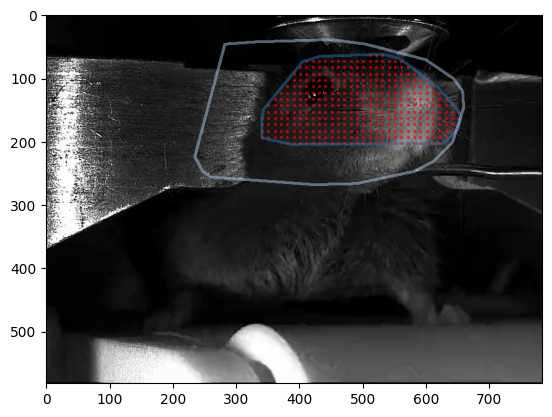

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [22]:
rois.plot_rois(exampleImage)

# Point Tracking

Prepare `PointTracker` object.\
Set `visualize_video` to **`True`** to tune parameters until they look appropriate, then set to **`False`** to run the full dataset through at a much faster speed.

Key parameters:
- `mesh_rigidity`: how rigid the mesh elasticity is. Vary so that points remain spatially coherent while still moving with the image.
- `relaxation`: how quickly the points relax back to their home position. Vary so that points don't drift while still moving with the image.
- `kwargs_method - winSize`: the spatial size of the optical flow calculation. Smaller is better but noisier, larger is less accurate but more robust to noise.
- `params_outlier_handling - threshold_displacement`: point displacements above this value will result in freezing of the points.
- `params_clahe`: It can be useful (though not always necessary) to apply [CLAHE](https://en.wikipedia.org/wiki/Adaptive_histogram_equalization) to the images to help with tracking. You can tune the spatial frequency with `tileGridSize`, and the strength of the normalization with `clipLimit`.

Other parameters like `maxLevel` and `criteria` tend not to matter much. You can look at this documentation if you want to fine tune the Lucas-Kanade optimization: https://docs.opencv.org/4.x/dc/d6b/group__video__track.html#ga473e4b886d0bcc6b65831eb88ed93323

In [23]:
pt = fr.point_tracking.PointTracker(
    visualize_video=True,  ## Set to True to preview tracking in a cv2 window.
    buffered_video_reader=videos,
    point_positions=rois.point_positions,
    rois_masks=[rois[1]],  ## selecting the second ROI to mask out the background.
    contiguous=True,
    params_optical_flow={
        "method": "lucas_kanade",
        "mesh_rigidity": 0.001,
        "mesh_n_neighbors": 70,
        "relaxation": 0.001,
        "kwargs_method": {
            "winSize": [65, 65],
            "maxLevel": 2,
            "criteria": [cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 2, 0.0003],
        },        
    },
    params_clahe={
        "clipLimit": 60.0,
        "tileGridSize": (250, 250),
    },
    params_visualization={
        'alpha': 0.9,
        'point_sizes': 3,
    },
    params_outlier_handling = {
        'threshold_displacement': 120,  ## Maximum displacement between frames, in pixels.
        'framesHalted_before': 10,  ## Number of frames to halt tracking before a violation.
        'framesHalted_after': 10,  ## Number of frames to halt tracking after a violation.
    },
    idx_start=0,  ## Frame index to start visualization from; only affects visualize_video=True preview.
    verbose=2,
)

FR: CUDA OpenCV not available, using CPU optical flow
FR: 368 points will be tracked
FR: Collapsing mask ROI images into single mask
FR: Initializing mesh distances
FR: Preparing playback visualizer


Perform point tracking

In [24]:
pt.track_points()

FR: Setting initial frame_prev
FR: Iterating point tracking through videos


video #:   0%|          | 0/1 [00:00<?, ?it/s]

frame #:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

Save the `PointTracker` object in 'analysis_files' project directory.\
Using compression can reduce file sizes slightly but is very slow.

In [ ]:
pt.save_config(path_config=path_config, overwrite=True, verbose=1)
pt.save_run_info(path_config=path_config, overwrite=True, verbose=2)
pt.save_run_data(path_config=path_config, overwrite=True, use_compression=False, verbose=1)

Clear some memory if needed. Optional.

In [ ]:
pt.cleanup()

Load the `PointTracker` data as a dictionary

In [ ]:
pt_data = fr.h5_handling.simple_load(str(Path(directory_project) / 'analysis_files' / 'PointTracker.h5'), return_dict=True, verbose=True)

# Spectral Analysis

This step generates spectrograms using the variable-Q transform.
Prepare `VQT_Analyzer` object.

Key parameters:
- `Q_lowF`:  Quality of the lowest frequency band of the spectrogram. Q value is number of oscillation periods. It's wise to keep Q values above 3. Setting it low gives good temporal resolution but poor frequency resolution; setting it high gives the opposite.
- `Q_highF`: Quality of the highest frequency band.
- `F_min`: Lowest frequency band to use.
- `F_max`: Highest frequency band to use.
- `downsample_factor`: How much to downsample the spectrogram by in time.
- `return_complex`: Whether or not to return the complex spectrogram. Generally set to False unless you want to try something fancy.

In [ ]:
%matplotlib inline
Fs = fr.util.load_run_info_file(path_run_info)['Dataset_videos']['frame_rate']

spec = fr.spectral_analysis.VQT_Analyzer(
    params_VQT = {
        'Fs_sample': Fs,
        'Q_lowF': 4,
        'Q_highF': 8,
        'F_min': 1.0,
        'F_max': data.frame_rate//2,
        'n_freq_bins': 25,
        'win_size': 301,
        'plot_pref': True,
        'downsample_factor': 8,
        'padding': 'valid',
    },
    batch_size=10,
    device=fr.helpers.set_device(use_GPU=True),
    normalization_factor=0.95,
    spectrogram_exponent=1.0,
    one_over_f_exponent=0.5,
    verbose=2,
)

Look at a demo spectrogram of a single point.\
Specify the point with the `idx_point` and `name_points` fields.\
Note that the `pt_data['points_tracked']` dictionary holds subdictionaries withe numeric string names (ie `['0'], ['1']`) for each video.

In [ ]:
%matplotlib notebook
spec_demo, xAxis_demo, freqs_demo = spec.demo_transform(
    points_tracked=pt_data['points_tracked'],
    point_positions=pt_data['point_positions'],
    idx_point=0,
    name_points='0',
    plot=True,
);

Generate spectrograms

In [ ]:
spec.transform_all(
    points_tracked=pt_data['points_tracked'],
    point_positions=pt_data['point_positions'],
)

Save the `VQT_Analyzer` object in 'analysis_files' project directory.\
Using compression can reduce file sizes slightly but is very slow.

In [ ]:
spec.save_config(path_config=path_config, overwrite=True, verbose=1)
spec.save_run_info(path_config=path_config, overwrite=True, verbose=1)
spec.save_run_data(path_config=path_config, overwrite=True, use_compression=False, verbose=1)

Clear some memory if needed. Optional.

In [ ]:
spec.cleanup()

Load the `VQT_Analyzer` data as a dictionary

In [ ]:
spec_data = fr.h5_handling.simple_load(str(Path(directory_project) / 'analysis_files' / 'VQT_Analyzer.h5'), return_dict=True, verbose=True)

# Decomposition

Prepare tensor component analysis `TCA` object, and then rearrange the data with the `.rearrange_data` method.

Key parameters for `.rearrange_data`:
- `names_dims_array`:  Enter the names of the dimensions of the spectrogram. Typically these are `'xy', 'points', 'frequency', 'time'`.
- `names_dims_concat_array`: Enter any dimensions you wish to concatenate along other dimensions. Typically we wish to concatenate the `'xy'` dimension along the `'points'` dimension, so we make a list containing that pair as a tuple: `[('xy', 'points')]`.
- `concat_complexDim`: If your input data are complex valued, then this can concatenate the complex dimension along another dimension.
- `name_dim_dictElements`: The `data` argument is expected to be a dictionary of dictionaries of arrays, where the inner dicts are trials or videos. This is the name of what those inner dicts are. Typically `'trials'`.

In [ ]:
spectrograms = {key: np.abs(val) for key,val in spec_data['spectrograms'].items()}

tca = fr.decomposition.TCA(verbose=2)

tca.rearrange_data(
    data=spectrograms,
    names_dims_array = ['xy', 'points', 'frequency', 'time'],
    names_dims_concat_array = [('xy', 'points')],
    concat_complexDim=False,
    name_dim_concat_complexDim='time',
    name_dim_dictElements = 'session',
    method_handling_dictElements = 'separate',
    name_dim_concat_dictElements = 'time',
    idx_windows=None,
    name_dim_array_window='time',
)

Optionally, you can normalize along a specified axis

In [ ]:
tca.normalize_data(
    mean_subtract=False,
    std_divide=True, 
    dim_name='time', 
)

Fit TCA model.

There are a few methods that can be used:
- `'CP_NN_HALS'`: non-negative CP decomposition using the efficient HALS algorithm. This should be used in most cases.
- `'CP'`: Standard CP decomposition. Use if input data are not non-negative (if you are using complex valued spectrograms or similar).
- `'Randomized_CP'`: Randomized CP decomposition. Allows for large input tensors. If you are using huge tensors and you are memory constrained or want to run on a small GPU, this is your only option.

If you have and want to use a CUDA compatible GPU:
- Set `DEVICE` to `'cuda'`
- GPU memory can be saved by setting `'init'` method to `'random'`. However, fastest convergence and highest accuracy typically come from `'init': 'svd'`.

In [ ]:
tca.fit(
    method='CP_NN_HALS',
    params_method={
        'rank': 10, 
        'n_iter_max': 1000, 
        'init': 'random', 
        'svd': 'truncated_svd', 
        'tol': 1e-09, 
        'verbose': True, 
    },
    DEVICE=fr.helpers.set_device(use_GPU=True),
    verbose=2,
)

Rearrange the factors.\
You can undo the concatenation that was done during `.rearrange_data`

In [ ]:
tca.rearrange_factors(
    undo_concat_complexDim=False,
    undo_concat_dictElements=False,
)

Save the `TCA` object in 'analysis_files' project directory.

In [ ]:
tca.save_config(path_config=path_config, overwrite=True, verbose=1)
tca.save_run_info(path_config=path_config, overwrite=True, verbose=1)
tca.save_run_data(path_config=path_config, overwrite=True, use_compression=False, verbose=1)

Clear some memory if needed. Useful if you ran the fit on a GPU. Optional.

In [ ]:
tca._cleanup()

## Plot the fitted TCA factors (spatial / spectral / temporal) for inspection.

In [ ]:
%matplotlib inline
tca.plot_factors(
    figure_saver=None,
    show_figures=True,
)

# Visualize results

Load the `PointTracker`, `TCA`, and `VQT` data as dictionaries

In [ ]:
tca_data  = fr.h5_handling.simple_load(str(Path(directory_project) / 'analysis_files' / 'TCA.h5'), return_dict=True)
spec_data = fr.h5_handling.simple_load(str(Path(directory_project) / 'analysis_files' / 'VQT_Analyzer.h5'), return_dict=True)
pt_data   = fr.h5_handling.simple_load(str(Path(directory_project) / 'analysis_files' / 'PointTracker.h5'), return_dict=True)

visualize the spectral factors and corresponding spatial factors

In [ ]:
fig_tca_specFactor = plt.figure()
plt.plot(spec_data['frequencies'], tca_data['factors']['0']['frequency'])
plt.xscale('log')
plt.xlabel('frequency')
plt.legend(np.arange(tca_data['factors']['0']['frequency'].shape[1]) + 1);
plt.show()

Save figure

In [ ]:
figure_saver.save_figure(
    fig=fig_tca_specFactor,
    name_save='fig_tca_specFactor',
)

visualize the point factor magnitudes

In [ ]:
cmap = fr.helpers.simple_cmap(
    colors=[[0,0,0], [1,0,0], [1,1,0]], 
    over=[0,1,0], 
    under=[0,1,0], 
    bad=[0,1,0], 
)

factor_values = tca_data['factors_rearranged']['0']['(xy points)']
factor_magnitudes = np.linalg.norm(factor_values.reshape(2, factor_values.shape[0]//2, -1), axis=0)

pts_tmp = pt_data['point_positions']
im_tmp = videos.video_readers[0][0].cpu().numpy()

frame_visualizer = fr.visualization.FrameVisualizer(
    verbose=2,
    frame_height_width=videos.frame_height_width,
    point_sizes=3,
    alpha=0.6,
)

ims_factors_points = [frame_visualizer.visualize_image_with_points(image=im_tmp, points=pts_tmp, points_colors=[(cmap(f/f.max())*255).astype(np.int64)[:,:3]]) for f in factor_magnitudes.T] 

fr.visualization.display_toggle_image_stack(ims_factors_points)

### Save images

Prepare an image saving helper class. It can save individual images in multiple formats as well as a list of images as a GIF.

In [ ]:
image_saver = fr.util.Image_Saver(
    path_config=path_config,
    dir_save=None,
    overwrite=True,
    verbose=1,
)

save individual factor images

In [ ]:
[image_saver.save_image(
    array_image=im,
    name_save=f'im_factors_points_{ii+1}',
    formats_save=['png'],
) for ii, im in enumerate(ims_factors_points)];

save gif of all the images

In [ ]:
image_saver.save_gif(
    array_images=fr.helpers.add_text_to_images(
        images=ims_factors_points,
        text=[[f'factor: {ii+1}'] for ii in range(len(ims_factors_points))],
        position=(10, 40),
        font_size=1,
        line_width=2,
        color=(255,255,255),
    ),
    name_save='im_factors_points',
    frame_rate=2.0,
    loop=0,
);

# Demo playback

Playback a video with points overlayed.\
Make sure you have a `BufferedVideoReader` object called `videos` made of your videos

In [ ]:
idx_video_to_use = 0
idx_frames_to_use = np.array(list(np.arange(0, 250*20)), dtype=np.int64)

videos.method_getitem = 'by_video'

frame_visualizer = fr.visualization.FrameVisualizer(
    display=False,  ## Set to True to play the video in a cv2 window (requires GUI cv2 build).
    error_checking=True,
    verbose=2,
    # path_save=str(Path(directory_project) / 'visualizations' / 'point_tracking_demo.avi'),
    path_save=None,  ## set to a .avi path to record the preview.
    frame_height_width=videos.frame_height_width,
    frame_rate=data.frame_rate,
    point_sizes=3,
    points_colors=(0,255,255),
    alpha=0.6,
)

fr.visualization.play_video_with_points(
    bufferedVideoReader=videos[idx_video_to_use],
    frameVisualizer=frame_visualizer,
    points=list(pt_data['points_tracked'].values())[0],
    idx_frames=idx_frames_to_use,
)